# Model creation

This notebook will includes the process of building and training my model. I began by testing the model that I used for the single-digit classifier to see it's performance on the three-digit dataset. I then tested a CNN only model, as well as a CNN combined a transformer with self-attention.

Please note that these training these models without GPU will take longer than desired. I recommend uploading this notebook to Colab or another environment with GPUs if you wish to replicate this work. I have also provided the models in the [/models](../models) folder if you would rather load models that I have trained using the code below.

## Load requirements

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch version: {torch.__version__}")
print("Setup complete!")

PyTorch version: 2.10.0+cu128
Setup complete!


If you are using Google Colab, please run the cell (skip otherwise). Place any files you will need access to in your Google Drive under the directory `DS593/` or modify the paths as needed.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load preprocessed dataset

Load the dataset from [preprocessing.ipynb](preprocessing.ipynb). If you are using Google Colab, please follow the directions above.

In [4]:
# Uncomment for Google Colab
dataset = torch.load("/content/drive/My Drive/DS593/multi_mnist.pt") # Modify this path to match where you saved the preprocessed dataset.

# Uncomment for local
# dataset = torch.load("../data/MNIST/multi_mnist.pt")

images = dataset["images"]
labels = dataset["labels"]

To verify the load, print out one of the items from the dataset.

torch.Size([1, 28, 84]) tensor(16)


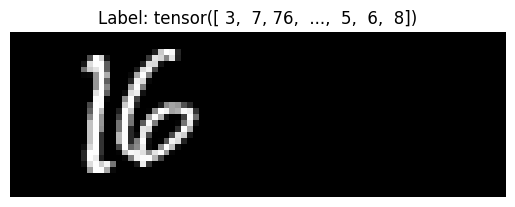

In [ ]:
print(images[6].shape, labels[6])
image_tensor = images[6]
plt.imshow(image_tensor[0, 0:28, 0:84], cmap='gray')
plt.title(f"Label: {labels}")
plt.axis("off")
plt.show()

## Simple Neural Network

For lab 3, I created a simple neural network to classify MNIST images. This was done on the original MNIST dataset, which only contains single-digit images. Multi-digit images are much more complex for a computer to process, especially with variable spacing between digits, so I was curious how the model I had previously trained would perform on the multi-digit dataset created during the preprocessing phase.

In [28]:
# Split into training and testing sets
tensors = dataset["images"].float() / 255.0
labels = dataset["labels"]

X_train, X_test, y_train, y_test = train_test_split(tensors, labels, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"X_train shape: {X_train.shape}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Input features: {X_train.shape[1]}")
print(f"Classes: {len(np.unique(labels))}")

Training samples: 48960
X_train shape: torch.Size([48960, 1, 28, 84])
Testing samples: 12240
Input features: 1
Classes: 493


My original model needed to be flattened to a 2D tensor.

In [ ]:
## Reshaping (flattening) so that we can perform matrix multiplication in the model
print(f"X_train shape before: {X_train.shape}")
print(f"X_test shape before: {X_test.shape}")

X_train = X_train.view(X_train.size(0), -1)
X_test = X_test.view(X_test.size(0), -1)

print(f"X_train shape after: {X_train.shape}")
print(f"X_test shape after: {X_test.shape}")

X_train shape before: torch.Size([48960, 1, 28, 84])
X_test shape before: torch.Size([12240, 1, 28, 84])
X_train shape after: torch.Size([48960, 2352])
X_test shape after: torch.Size([12240, 2352])


My simple neural network use stochastic gradient descent as an optimizer for its ability to escape local minima and its quick convergence. I chose cross-entropy for my loss function to better describe the loss with many classes (10). In my lab, I ran tests using various combinations or learning rates, hidden sizes, and batch sizes, but found for the one-digit classification task, a learning rate of 0.04 yielded the highest accuracy. I chose 256 for the hidden layer size to capture enough detail while also being few enough to run on CPU or GPU. I chose used a larger batch size to train faster, although smaller batch sizes are often recommended to caputre noise, keeping the model from getting stuck in local minima. Adjusting the batch size might improve the result of this model.

In [ ]:
# Define neural network using PyTorch
class NormalizedNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, debug=False):
        super().__init__()
        # Define layers: input -> hidden -> output
        self.hidden = nn.Linear(input_size, hidden_size)
        self.output = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
        self.debug = debug

        # Normalization for ReLU
        nn.init.kaiming_normal_(self.hidden.weight, nonlinearity="relu")
        nn.init.zeros_(self.hidden.bias)

    def forward(self, x):
        """Forward pass through the network"""
        # Pass through hidden layer with sigmoid activation
        hidden_out = self.relu(self.hidden(x))
        # Adding a debug statement to check if the hidden layer is other than zero.
        if self.debug is True:
            print('forward pass')
            print(hidden_out.min().item(), hidden_out.max().item())
        # Pass through output layer with sigmoid activation
        output = self.output(hidden_out)
        return output

In [ ]:
## Creating a function make it easier to experiment with model parameters
def create_model_with_params(ModelClass, hidden_size, lr, debug=False):
    model = ModelClass(input_size=2352, hidden_size=hidden_size, output_size=1000, debug=debug)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)  # Stochastic Gradient Descent

    print(model)
    print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")
    print("Loss function: Cross-Entropy")
    print(f"Optimizer: SGD with learning rate {lr}")
    return model, criterion, optimizer

In [ ]:
# Training loop with PyTorch
def train_batch_nn_model(model, criterion, optimizer, X_train, y_train,
                   batch_size=64, num_epochs=1000, debug=True, return_loss=False):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = criterion.to(device)
    model.train()
    pytorch_loss_history = []

    print("Training with PyTorch autograd...")

    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            # Forward pass: compute predictions
            predictions = model(X_batch)

            # Compute loss
            loss = criterion(predictions, y_batch)
            pytorch_loss_history.append(loss.item())

            # Backward pass: PyTorch automatically computes gradients!
            optimizer.zero_grad()  # Clear previous gradients
            loss.backward()  # Compute gradients (backpropagation)
            optimizer.step()  # Update weights using gradients

            epoch_loss += loss.item()

        # Print progress every 100 epochs
        if debug is True and (epoch + 1) % 100== 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

        if loss.item() < 0.001:
            print("Loss is below threshold of 0.001. Stopping training.")
            break

    print("\nTraining complete!")
    print(f"Final loss: {pytorch_loss_history[-1]:.4f}")

    if return_loss:
        return model, pytorch_loss_history

    return model

In [ ]:
# Evaluate PyTorch model on test set
def evaluate_batch_model(model, X_test, y_test, batch_size=256):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()  # Set model to evaluation mode

    test_dataset = TensorDataset(X_test, y_test)
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    correct = 0
    total = 0

    with torch.no_grad():  # turn off gradients for inference
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)          # shape: [num_samples, 10]
            predicted = torch.argmax(outputs, dim=1)  # get predicted class indices
            correct += (predicted == y_batch).sum().item()  # count correct predictions
            total += y_batch.size(0)  # divide by total samples

    accuracy = correct / total
    print(f"PyTorch Model Test Accuracy: {accuracy* 100:.2f}%")
    return accuracy

In [ ]:
## Plot the loss of a model
def plot_loss(loss_history):
  plt.figure(figsize=(12, 5))

  plt.subplot(1, 2, 2)
  plt.plot(loss_history, label='PyTorch Autograd', color='orange', linewidth=2)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('PyTorch Autograd')
  plt.grid(True, alpha=0.3)
  plt.legend()

  plt.tight_layout()
  plt.show()

I defined the different steps used in training, evaluating, and visualizing the model above so that they can more easily be recycled or adapted for similar purposes.

In [ ]:
model, criterion, optimizer = create_model_with_params(NormalizedNet, 256, 0.04, debug=False)
model, loss_history = train_batch_nn_model(model, criterion, optimizer, X_train, y_train, batch_size=64, num_epochs=500, return_loss=True)
accuracy = evaluate_batch_model(model, X_test, y_test)


NormalizedNet(
  (hidden): Linear(in_features=2352, out_features=256, bias=True)
  (output): Linear(in_features=256, out_features=1000, bias=True)
  (relu): ReLU()
)

Total parameters: 859368
Loss function: Cross-Entropy
Optimizer: SGD with learning rate 0.04
Training with PyTorch autograd...
Epoch 100/500, Loss: 2.3050
Epoch 200/500, Loss: 2.0029
Epoch 300/500, Loss: 1.8590
Epoch 400/500, Loss: 1.6927
Epoch 500/500, Loss: 1.2060

Training complete!
Final loss: 1.2060
PyTorch Model Test Accuracy: 58.21%


Note, please change the path below to the `../models` folder if you are running locally.

In [ ]:
# Saving model so I don't have to regenerate it
torch.save(model.state_dict(), "/content/drive/My Drive/DS593/normalized_net_model_state.pt")

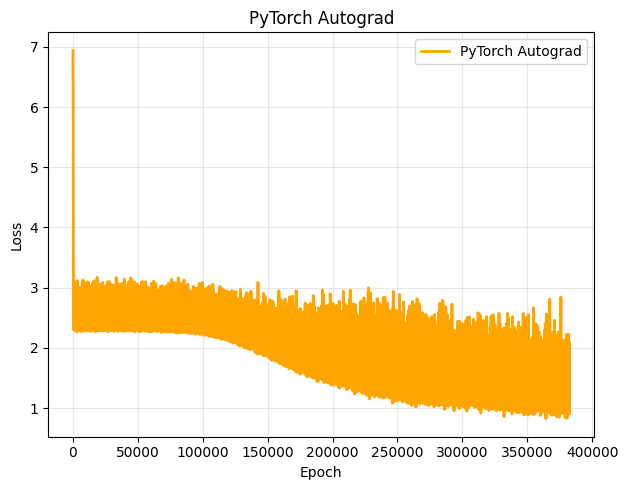

In [ ]:
plot_loss(loss_history)

Using the NN as it worked for single digits clearly is not yielding convincing results on the multi-digit dataset (only 58% accuracy). While the model hyperparameters could be adjusted for better performance, I am interested in trying another method to see how it compares.

## Encoder-Decoders Transformer for Multi-Digit MNIST

To cover more of our course topics, I am interested in seeing how a encoder-decoder transformer behaves with the MNIST dataset. While we talked about transformers primarily in the context of language, I am will attempt to transition the pixel data into sequential spatical data that can be use to identify how many digits there are in a given images (could be anywhere from 1-3) and correctly classify them.

This section requires more resources, so I recommend using a device with GPUs or Google Colab. All of the code may be run on CPU only, but it will take much longer. For convenience, I've placed the final version of both models in the [../models](../models) folder so that if you want to test without retraining, you may simply load the model states.

In [5]:
## Check for GPU Availability on your device
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("CPU only - consider using GPU for faster training")

CUDA available: True
Device: cuda
GPU Name: Tesla T4
GPU Memory: 15.64 GB


I've pulled out the parameters to the top for visibility. Briefly the parameters available include:

  - DEVICE: determined by GPU availablity
  - IN_CH: the number of channels. In this case, it will alway be 1, but if running with color, it should be set to 3.
  - IMG_H: pixel height of the image. In this case, 28 pixels.
  - IMG_W: pixel width of the image. In this case, 84 pixels.
  - BATCH_SIZE: the number of images per training batch. As mentioned above, a smaller value can add in meaningful noise.
  - EPOCHS: The number of training epochs. I chose 10 to reduce the number of resources needed by repeatedly comupting.
  - LR: Because I'm using ADAM, I chose a smaller learning rate to ensure I am not jumping too far with each step.
  - D_MODEL: To balance compatability with CPU, I chose a smaller D_MODEL to lower the computational resources needed while still being able to capture enough detail to be meaningful.
  - DEC_LAYERS: decoder layers. To run swiftly, I chose 2.
  - MAX_OUTPUT_LEN: the longest sequence can be 5 (3 digit, start and end of sequence)
  - NUM_CLASSES_DIGIT: 10, to capture the 0..9 possible digits
  - SOS_TOKEN: start of sequence token, arbitrary
  - EOS_TOKEN: end of sequence token, arbitrary
  - PAD_TOKEN = padding token for postition that do not hold a start, end, or digit.
  - vocab: maps the tokens to their integer form
  - id2token: maps ids to tokens

In [11]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IN_CH = 1
IMG_H, IMG_W = 28, 84
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-4
D_MODEL = 64
NHEAD = 4
DEC_LAYERS = 2
MAX_OUTPUT_LEN = 6   # includes SOS/EOS; greater than 3+2
NUM_CLASSES_DIGIT = 10  # digits 0..9

# token names
SOS_TOKEN = "A"
EOS_TOKEN = "Z"
PAD_TOKEN = "<PAD>"

vocab = {str(d): d for d in range(NUM_CLASSES_DIGIT)}
vocab[SOS_TOKEN] = NUM_CLASSES_DIGIT
vocab[EOS_TOKEN] = NUM_CLASSES_DIGIT + 1
vocab[PAD_TOKEN] = NUM_CLASSES_DIGIT + 2
id2token = {i: t for t, i in vocab.items()}
SOS_ID = vocab[SOS_TOKEN]
EOS_ID = vocab[EOS_TOKEN]
PAD_ID = vocab[PAD_TOKEN]
VOCAB_SIZE = len(vocab)

I'm begining with a CNN because they excel working with images and spacial patterns. While we didn't go over it in depth in class, we touched on it in the Deep Learning lecture. For more context on how to build a CNN, I referenced [this Medium article](https://medium.com/@ponchanon.rone/building-a-cnn-for-handwritten-digit-recognition-with-pytorch-a-step-by-step-guide-9df1dcb1092d).

Note that below Hf and Wf are equal to H/4 and W/4 respectively because each pool reduces the spacial resolution by a factor of 2. There are 2 pools in this model.

In [6]:
class SmallCNNEncoder(nn.Module):
    def __init__(self, in_ch, feat_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # H/2, W/2
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # H/4, W/4
            nn.Conv2d(128, feat_dim, 3, padding=1), nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)  # (B, feat_dim, Hf, Wf)

I decided to use a Learned 2D positional encoder because I read that they common in Vision Transformers. It will create positional embeddings for each image that capture information in a 2D grid.

In [7]:
# 2D positional encoding (learned)
class Learned2DPosEnc(nn.Module):
    def __init__(self, Hf, Wf, d_model):
        super().__init__()
        # Creating the learnable embedding for each row / column
        self.row_embed = nn.Parameter(torch.randn(Hf, d_model) * 0.02)
        self.col_embed = nn.Parameter(torch.randn(Wf, d_model) * 0.02)
    def forward(self, x):
        # B is batcch size
        # seq_len is Hf*Wf
        # d_model: the embedding dimension chosen
        B, seq_len, d = x.shape
        Hf = self.row_embed.shape[0]
        Wf = self.col_embed.shape[0]
        # build (Hf, Wf, d) positional embeddings by adding d associated with Hf and Wf with the shape (Hf, Wf, d)
        pe = (self.row_embed[:, None, :] + self.col_embed[None, :, :])
        # Flattening to match the sequence format with the shape (Hf*Wf, d)
        pe = pe.view(-1, d)
        pe = pe.unsqueeze(0).expand(B, -1, -1)
        # Returns the positional and token embeddings added together
        return x + pe.to(x.device)

Putting the two pieces above together, we get the features from the CNN and from the 2D positional encoder. Together, the create the encoder that turns our 2D MNIST (modified) dataset into sequences of spacial tokens.

In [13]:
# Encoder
class ImageEncoder(nn.Module):
    def __init__(self, input_channels, d_model, H, W):
        super().__init__()
        self.cnn = SmallCNNEncoder(input_channels, feat_dim=d_model)
        # Reduce to match the spacial resolution reduction done by the CNN
        Hf = H // 4
        Wf = W // 4
        self.Hf, self.Wf = Hf, Wf
        # Projection layer to apply the linear transformation to each token
        self.proj = nn.Linear(d_model, d_model)
        # 2D positional encoding to create the positional embeddings on a spatial grid
        self.posenc = Learned2DPosEnc(Hf, Wf, d_model)
    def forward(self, x):
        # Perform CNN feature extraction outputting shape (batch_size, d_model, Hf, Wf)
        feat = self.cnn(x)
        B, C, Hf, Wf = feat.shape
        # Converting the 2D grid into a sequence with the shape (batch_size, seq_len, d_model)
        seq = feat.permute(0, 2, 3, 1).reshape(B, Hf*Wf, C)
        # Perform linear projection
        seq = self.proj(seq)
        # Add in the positional encoding so that the row and column embedding information is combined.
        seq = self.posenc(seq)
        # seq shape is (batch_size, seq_len, d_model)
        return seq


Next, I wanted to use a sequence-to-sequence decoder to explore some of the concepts we covered in class. I was curious how this would work with image data since we mostly covered it in the context of language, but the sequences of image data should still help the model to decode what digit it most similar.

Note that below, the positional embedding `pos_embed` is a 1-D positional encoding becuase it only is looking at the position index rather than a grid of spatial data.

I also leveraged some of PyTorch's exisiting NN functionality, as seen below with TransformerDecoderLayer. This allowed me to incorporate masked-self attention (as the decoder decodes the sequence, preventing it from looking ahead) and cross-attention (as it incorporates information from the encoder). It also handles the feed-forward network step of the decoder.

In [12]:
# Decoder
class TransformerDecoder(nn.Module):
    def __init__(self, d_model, nhead, num_layers, vocab_size, max_len):
        super().__init__()
        self.d_model = d_model
        # Creates the token embedding
        self.token_embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        # Creates the positional embedding
        self.pos_embed = nn.Embedding(max_len, d_model)
        # Decoder layers
        decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*4, batch_first=True)
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        # Converts the decoder back to the "vocabulary"
        self.out_proj = nn.Linear(d_model, vocab_size)
    def forward(self, tgt_tokens, memory, tgt_mask=None, tgt_key_padding_mask=None):
        # tgt_tokens: (B, T) token ids (including <sos> prefix), memory: (B, S, d_model)
        B, T = tgt_tokens.shape
        positions = torch.arange(T, device=tgt_tokens.device).unsqueeze(0).expand(B, T)
        tgt = self.token_embed(tgt_tokens) + self.pos_embed(positions)
        # decoder returns (B, T, d_model)
        dec = self.decoder(tgt, memory, tgt_mask=tgt_mask, tgt_key_padding_mask=tgt_key_padding_mask)
        logits = self.out_proj(dec)  # (B, T, vocab_size)
        return logits


I decided to try use greedy decoding for because of its speed and its lower memory cost. It is also deterministic, which in this case, is a plus because we want every number to always map to itself.

The mask is used to hide values from the decoder before it is allowed to see them (can only look back) by building a matrix that hides future positions with `-inf`. The `-inf` values are filled in on the upper-triangluar portion of the positions matrix. With `softmax`, `-inf` gets squashed to 0, preventing attention on those tokens.

In [14]:
# Helper to create causal mask for decoder (so token t can only attend to <=t)
def generate_square_subsequent_mask(sz, device):
    mask = torch.triu(torch.ones(sz, sz, device=device) * float('-inf'), diagonal=1)
    return mask

# Greedy autoregressive decoding
@torch.no_grad()
def greedy_decode(model, images, max_len=10):
    model.eval()
    B = images.shape[0]
    # Memory hold the encoder output, which is attended to at every step
    memory = model.encoder(images)  # (B, S, d_model)
    # Puts the start of sequence id at the front of every sequence
    ys = torch.ones(B, 1, dtype=torch.long, device=images.device) * model.sos_id
    # Keeps track of which sequences are finished, indicated by the end of sequence token
    finished = torch.zeros(B, dtype=torch.bool, device=images.device)
    outputs = []
    for i in range(max_len):
        # Masks future tokens
        tgt_mask = generate_square_subsequent_mask(ys.size(1), device=DEVICE)
        # Runs the decoder
        logits = model.decoder(ys, memory, tgt_mask=tgt_mask)  # (B, T, vocab)
        # Predicts the next token, taking the one with the highest probability
        next_logits = logits[:, -1, :]  # (B, vocab)
        next_tokens = next_logits.argmax(dim=-1, keepdim=True)  # (B,1)
        ys = torch.cat([ys, next_tokens], dim=1)
        outputs.append(next_tokens)
        # Sequences are marked as finished when EOS appears
        finished = finished | (next_tokens.squeeze(1) == model.eos_id)
        if finished.all():
            break
    # Remove the start/end of sequence tokens
    seqs = []
    ys = ys[:, 1:]
    # Converts the tokens back to strings
    for b in range(B):
        seq = []
        for tok in ys[b].cpu().tolist():
            if tok == model.eos_id or tok == model.pad_id:
                break
            # Check that it is a valid digit
            if tok < NUM_CLASSES_DIGIT:
                seq.append(str(tok))
        seqs.append("".join(seq))
    return seqs

Placing the two pieces together:

In [29]:
class CNNEncoderDecoder(nn.Module):
    def __init__(self, in_ch, img_h, img_w, d_model, nhead, num_layers, vocab_size, max_len):
        super().__init__()
        self.encoder = ImageEncoder(in_ch, d_model, img_h, img_w)
        self.decoder = TransformerDecoder(d_model, nhead, num_layers, vocab_size, max_len)
        self.sos_id = 10
        self.eos_id = 11
        self.pad_id = 12
    def forward(self, images, tgt_tokens, tgt_mask=None, tgt_key_padding_mask=None):
        # images: (B, C, H, W), tgt_tokens: (B, T) (with <sos> prefixed for teacher forcing)
        memory = self.encoder(images)
        logits = self.decoder(tgt_tokens, memory, tgt_mask=tgt_mask, tgt_key_padding_mask=tgt_key_padding_mask)
        return logits

The labels in the dataset do not contain start/end tokens that are needed for the encoder-decoder to function properly. `build_target_tensors()` adds these necessary tokens.

In [17]:
def build_target_tensors(labels, device):
    # labels: list of strings like "34", length B
    # returns tgt_in (B, T) with SOS prefix, padded; tgt_out (B, T) next-token targets (with PAD)
    token_seqs = []
    lengths = []
    for s in labels:
        toks = [SOS_ID] + [int(ch) for ch in s] + [EOS_ID]
        token_seqs.append(torch.tensor(toks, dtype=torch.long))
        lengths.append(len(toks))
    # determines the maximum length of the sequence (include SOS and EOS)
    maxT = max(lengths)
    B = len(labels)
    # Create tensors of only padding
    tgt_in = torch.full((B, maxT), PAD_ID, dtype=torch.long, device=device)
    tgt_out = torch.full((B, maxT), PAD_ID, dtype=torch.long, device=device)
    # Populate the tensors with the corrdct values
    for i, seq in enumerate(token_seqs):
        L = seq.numel()
        tgt_in[i, :L] = seq
        # next-token targets (shifted)
        if L > 1:
            tgt_out[i, :L-1] = seq[1:]
    return tgt_in, tgt_out

To train the model, each epoch builds to targets, masks future tokens, and employs the model to aquire prediction logits. The loss is calculated for loss is calculated for each image/label set and added to the total loss for the epoch before performing the back propogation.

In [18]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for images, labels in dataloader:
        images = images.to(device)
        tgt_in, tgt_out = build_target_tensors(labels, device)
        tgt_mask = generate_square_subsequent_mask(tgt_in.size(1), device=device)
        logits = model(images, tgt_in, tgt_mask=tgt_mask)
        B, T, V = logits.shape
        loss = criterion(logits.view(B*T, V), tgt_out.view(B*T))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(dataloader.dataset)

The last step involves evaluating the model. For simiplicty, I chose to calculate the model accuracy, but additional performance metrics should be calculated for more thourough testing. The sequence and position correctness are calculated seperately.

In [19]:
def evaluate(model, dataloader, device):
    model.eval()
    total = 0
    correct_seq = 0
    correct_pos = 0
    total_pos = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            preds = greedy_decode(model, images, max_len=MAX_OUTPUT_LEN)
            for p, gt in zip(preds, labels):
                total += 1
                if p == gt:
                    correct_seq += 1
                # position-wise: compare up to min length
                L = max(len(p), len(gt))
                total_pos += L
                for i in range(L):
                    pi = p[i] if i < len(p) else None
                    gi = gt[i] if i < len(gt) else None
                    if pi == gi:
                        correct_pos += 1
    seq_acc = correct_seq / total
    pos_acc = correct_pos / total_pos if total_pos>0 else 0.0
    return seq_acc, pos_acc

In [23]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class ImageDataset(Dataset):
    """
    Stores images as tensors and labels as strings.
    Expects images_tensor shape (N, C, H, W) or (N, H, W) and labels as ints or strings.
    """
    def __init__(self, images_tensor, labels, transform=None):
        # images_tensor: torch.Tensor (N, C, H, W) or (N, H, W)
        # labels: list/array of ints or str; each label can be an int representing the number like 34
        assert len(images_tensor) == len(labels)
        self.images = images_tensor
        self.labels = labels
        self.transform = transform

        # Ensure images have channel dimension (N, C, H, W)
        if self.images.dim() == 3:
            # (N, H, W) -> (N, 1, H, W)
            self.images = self.images.unsqueeze(1)
        elif self.images.dim() == 4:
            pass
        else:
            raise ValueError("images_tensor must be shape (N,H,W) or (N,C,H,W)")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        lbl = self.labels[idx]
        # Convert integer label to string if needed
        if isinstance(lbl, torch.Tensor):
            lbl = lbl.item()
        label_str = str(int(lbl))
        return img, label_str

def load_splits(images_tensor, labels, batch_size=32, val_fraction=0.1, test_fraction=0.2, random_state=42):
    """
    images_tensor: torch.Tensor shape (N, C, H, W) or (N, H, W), dtype uint8 or float
    labels: list/array of ints or strings, length N
    Returns: train_loader, val_loader, test_loader yielding (image_tensor, label_string)
    """
    N = len(images_tensor)
    # convert images to float32 in [0,1] if needed
    if not torch.is_floating_point(images_tensor):
        images_tensor = images_tensor.float() / 255.0

    # First split train+val vs test
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        images_tensor, labels, test_size=test_fraction, random_state=random_state
    )
    # Split train vs val
    val_size = val_fraction / (1.0 - test_fraction)  # fraction of trainval that goes to val
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=val_size, random_state=random_state
    )

    train_ds = ImageDataset(X_train, list(y_train))
    val_ds = ImageDataset(X_val, list(y_val))
    test_ds = ImageDataset(X_test, list(y_test))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader

In [24]:
# dataset

train_loader, val_loader, test_loader = load_splits(images, labels)

model = CNNEncoderDecoder(IN_CH, IMG_H, IMG_W, D_MODEL, NHEAD, DEC_LAYERS, VOCAB_SIZE, MAX_OUTPUT_LEN).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

for epoch in range(1, EPOCHS+1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    seq_acc, pos_acc = evaluate(model, val_loader, DEVICE)
    print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_seq_acc={seq_acc:.4f}, val_pos_acc={pos_acc:.4f}")
    # show some examples
    model.eval()
    with torch.no_grad():
        images, labels = next(iter(val_loader))
        images = images.to(DEVICE)
        preds = greedy_decode(model, images[:8], max_len=MAX_OUTPUT_LEN)
        for i in range(8):
            print(f"GT: {labels[i]:>4}  PRED: {preds[i]:>4}")
    # Save each epoch as a checkpoint (in case of interruption)
    torch.save(model.state_dict(), "model_state.pt")
    torch.save(model.state_dict(), f"/content/drive/My Drive/DS593/cnn_encdec_epoch{epoch}.pth")

Epoch 1: train_loss=0.7467, val_seq_acc=0.8917, val_pos_acc=0.8734
GT:    0  PRED:    0
GT:    2  PRED:    2
GT:    5  PRED:    5
GT:    9  PRED:    9
GT:    4  PRED:    4
GT:    4  PRED:    4
GT:    4  PRED:    4
GT:    9  PRED:    9
Epoch 2: train_loss=0.2091, val_seq_acc=0.9309, val_pos_acc=0.9142
GT:    0  PRED:    0
GT:    2  PRED:    2
GT:    5  PRED:    5
GT:    9  PRED:    9
GT:    4  PRED:    4
GT:    4  PRED:    4
GT:    4  PRED:    9
GT:    9  PRED:    9
Epoch 3: train_loss=0.1360, val_seq_acc=0.9469, val_pos_acc=0.9337
GT:    0  PRED:    0
GT:    2  PRED:    2
GT:    5  PRED:    5
GT:    9  PRED:    9
GT:    4  PRED:    4
GT:    4  PRED:    4
GT:    4  PRED:    4
GT:    9  PRED:    9
Epoch 4: train_loss=0.1078, val_seq_acc=0.9458, val_pos_acc=0.9299
GT:    0  PRED:    0
GT:    2  PRED:    2
GT:    5  PRED:    5
GT:    9  PRED:    9
GT:    4  PRED:    4
GT:    4  PRED:    4
GT:    4  PRED:    4
GT:    9  PRED:    9
Epoch 5: train_loss=0.0950, val_seq_acc=0.9574, val_pos_acc=

The final validation accuracy from training for the sequence was 96.8% and the position was 95.7%. These are both drastically improved from the original simple neural network that I attempted. To test the model further, I am evaluating on the 20% of data held out for testing.

In [25]:
def evaluate(model, dataloader, device):
    model.eval()
    total = 0
    correct_seq = 0
    correct_pos = 0
    total_pos = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            preds = greedy_decode(model, images, max_len=MAX_OUTPUT_LEN)
            for p, gt in zip(preds, labels):
                total += 1
                if p == gt:
                    correct_seq += 1
                # position-wise: compare up to min length
                L = max(len(p), len(gt))
                total_pos += L
                for i in range(L):
                    pi = p[i] if i < len(p) else None
                    gi = gt[i] if i < len(gt) else None
                    if pi == gi:
                        correct_pos += 1
    seq_acc = correct_seq / total
    pos_acc = correct_pos / total_pos if total_pos>0 else 0.0
    return seq_acc, pos_acc

In [26]:
seq_acc, pos_acc = evaluate(model, test_loader, DEVICE)

In [27]:
print(f'The sequence accuracy on the testing data is {seq_acc}')
print(f'The position accuracy on the testing data is {pos_acc}')

The sequence accuracy on the testing data is 0.9689542483660131
The position accuracy on the testing data is 0.9588160609427075


Here, the accuracy of on the testing data is vastly improved from the original model.

# Conclusions:

## Results

Compared to the Simple Normalized Neural Network, the CNN Encoder-Decoder Model performed much better on the dataset (baseline ≈ 58% accuracy vs. CNN encoder-decoder ≈ 95-96%). The improvement likely stems from two factors: 1)the CNN encoder produces locality-aware features that are more condusive to pattern recognition in visual data, and 2) the decoder with attention allows the model to understand parts of an image through sequences rather than attempting to look at and classify the entire image at once. The decoder's attention on allowed for alignment between output digits and image regions,  which led it to more accurately predict and classify images with various counts of handwritten digits.

## Reflection

Before settling on the encoder-decoder model outlined here, I also explored a few other avenues. My takeaways from this project include:

  - Clearly define the advantages and disadvantage of each model before embarking. I spent a lot of time building dead-end models only to realize that I was trying to make a class concept fit where it naturally did not.
  - Attention functions similarly for visual data as textual data. While this makes sense due to the preprocessing and tokenization, it was interesting to explore how image data could be reshaped so that sequences emerged to allow for decoder predictions.
  - Greedy decoding works well for classification problems where creativity is not necessary and determinability is preferred.
  - Checkpointing models frequently during training will save a lot of headache if the session is disconnected.


## Ideas for improvement

One area I didn't explore in this lab was visualizing the attention and cross attention in the encoder-decoder transformer. I was interested is looking at where the attention was focusing for different sequences, but was not able to implement an interpretable heatmap or other visualization.

Additionally, while I did test many other iterations of these two models on my way to develop them, they could be futher tested with various hyperparameters to improve performance (especially if GPU is available).

## AI Usage Statement

I used Claude Haiku for assistance when writing the more complex pieces of code. For any code that I used, I made through to go through line-by-line to make adjustments and add comments for claity, ensuring my understanding.